In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense

## Dataset

In [ ]:
def read_images_from_folder(folder_path, image_height, image_width):
    images = []
    labels = []
    label_to_index = {}  # Map label names to numerical indices
    index = 0

    for category in os.listdir(folder_path):
        label_to_index[category] = index
        category_folder = os.path.join(folder_path, category)

        if os.path.isdir(category_folder):
            for filename in os.listdir(category_folder):
                try:
                    image_path = os.path.join(category_folder, filename)
                    image = cv2.imread(image_path)
                    image = cv2.resize(image, (image_height, image_width))  # Resize image to desired dimensions
                    images.append(image)
                    labels.append(index)
                except:
                    print(filename)
        index += 1

    images = np.array(images)
    labels = np.array(labels)

    return images, labels, label_to_index

In [ ]:
folder_path = "/content/drive/MyDrive/pose Estimation"
# folder_path_test = "/home/somesh/Documents/datasets/my_data/test"
image_height = 64
image_width = 64

X, y, label_to_index = read_images_from_folder(folder_path, image_height, image_width)
# X_val, y_val, label_to_index = read_images_from_folder(folder_path_test, image_height, image_width)

print("Number of images:", len(X))
print("Number of labels:", len(y))
print("Label to index mapping:", label_to_index)

Number of images: 427
Number of labels: 427
Label to index mapping: {'Squating': 0, 'Bending': 1, 'Standing': 2}


In [ ]:
from sklearn.model_selection import train_test_split

# using the train test split function
X_train, X_val, y_train, y_val = train_test_split(X,y ,
                                   random_state=104,
                                   test_size=0.25,
                                   shuffle=True)

In [ ]:
y_val.shape

(107,)

In [ ]:
# Normalize pixel values to range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0

# Convert labels to one-hot encoding
num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_val = tf.keras.utils.to_categorical(y_val, num_classes)

## Pose Estimation

In [ ]:

def pose_classification_model(image_height, image_width, num_channels, sequence_length, num_classes):
    # Define CNN model for feature extraction
    cnn_model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(image_height, image_width, num_channels)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten()
    ])

    # Define LSTM model for sequence modeling
    lstm_model = Sequential([
        LSTM(128, return_sequences=True),
        LSTM(64),
        Dense(64, activation='relu')
    ])

    # Combine both models
    combined_model = Sequential([
        cnn_model,
        tf.keras.layers.RepeatVector(sequence_length),  # Repeat the output of CNN to feed into LSTM
        lstm_model,
        Dense(num_classes, activation='softmax')  # Output layer for classification
    ])

    # Compile the model
    combined_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return combined_model

In [ ]:
model = pose_classification_model(image_height=64, image_width=64, num_channels=3, sequence_length=10, num_classes=10)
model.summary()  # Print model summary

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 4608)              93248     
                                                                 
 repeat_vector (RepeatVecto  (None, 10, 4608)          0         
 r)                                                              
                                                                 
 sequential_1 (Sequential)   (None, 64)                2478912   
                                                                 
 dense_1 (Dense)             (None, 10)                650       
                                                                 
Total params: 2572810 (9.81 MB)
Trainable params: 2572810 (9.81 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Train the model
num_epochs = 20
batch_size = 32

history = model.fit(X_train, y_train,
                    epochs=num_epochs,
                    batch_size=batch_size,
                    validation_data=(X_val, y_val))

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_val, y_val)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Epoch 1/20
10/10 [==============================] - 0s 33ms/step - loss: 0.0094 - accuracy: 0.9969 - val_loss: 0.4026 - val_accuracy: 0.9346
Epoch 2/20
10/10 [==============================] - 0s 17ms/step - loss: 0.0084 - accuracy: 0.9969 - val_loss: 0.4316 - val_accuracy: 0.9346
Epoch 3/20
10/10 [==============================] - 0s 22ms/step - loss: 0.0082 - accuracy: 0.9969 - val_loss: 0.4996 - val_accuracy: 0.9346
Epoch 4/20
10/10 [==============================] - 0s 16ms/step - loss: 0.0753 - accuracy: 0.9750 - val_loss: 0.7509 - val_accuracy: 0.7944
Epoch 5/20
10/10 [==============================] - 0s 16ms/step - loss: 0.4925 - accuracy: 0.8094 - val_loss: 0.5554 - val_accuracy: 0.7850
Epoch 6/20
10/10 [==============================] - 0s 15ms/step - loss: 0.3043 - accuracy: 0.9031 - val_loss: 0.5903 - val_accuracy: 0.8598
Epoch 7/20
10/10 [==============================] - 0s 15ms/step - loss: 0.2057 - accuracy: 0.9469 - val_loss: 0.4043 - val_accuracy: 0.8879
Epoch 8/20
10

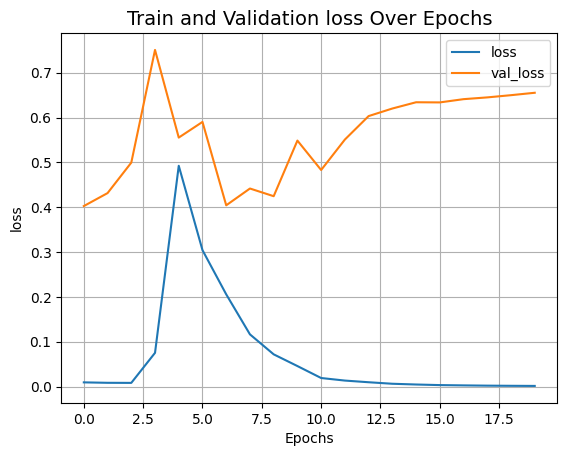

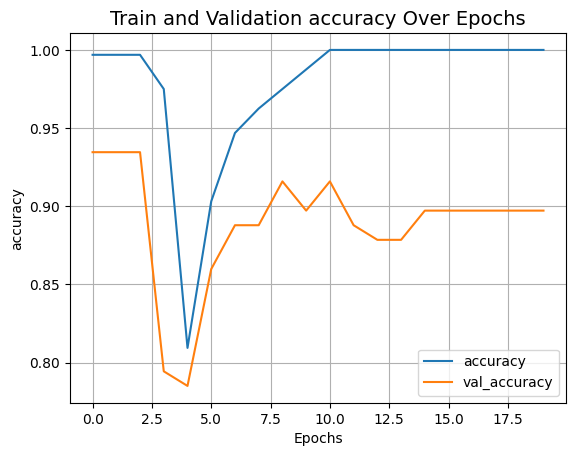

In [ ]:
import matplotlib.pyplot as plt

def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

plot_history("loss")
plot_history("accuracy")

In [ ]:
# prompt: give code to generate confusion matrix, recall, precision and f1-score for every class and overall

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Predict the labels for the validation set
y_pred = model.predict(X_val)

# Convert the predictions to class indices
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate the confusion matrix
confusion_matrix = confusion_matrix(y_val.argmax(axis=1), y_pred_classes)

# Print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix)

# Generate the classification report
classification_report = classification_report(y_val.argmax(axis=1), y_pred_classes)

# Print the classification report
print("\nClassification Report:")
print(classification_report)


4/4 [==============================] - 0s 7ms/step
Confusion Matrix:
[[46  0  3]
 [ 0  2  0]
 [ 5  3 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92        49
           1       0.40      1.00      0.57         2
           2       0.94      0.86      0.90        56

    accuracy                           0.90       107
   macro avg       0.75      0.93      0.80       107
weighted avg       0.91      0.90      0.90       107




Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92        49
           1       0.40      1.00      0.57         2
           2       0.94      0.86      0.90        56

    accuracy                           0.90       107
   macro avg       0.75      0.93      0.80       107
weighted avg       0.91      0.90      0.90       107



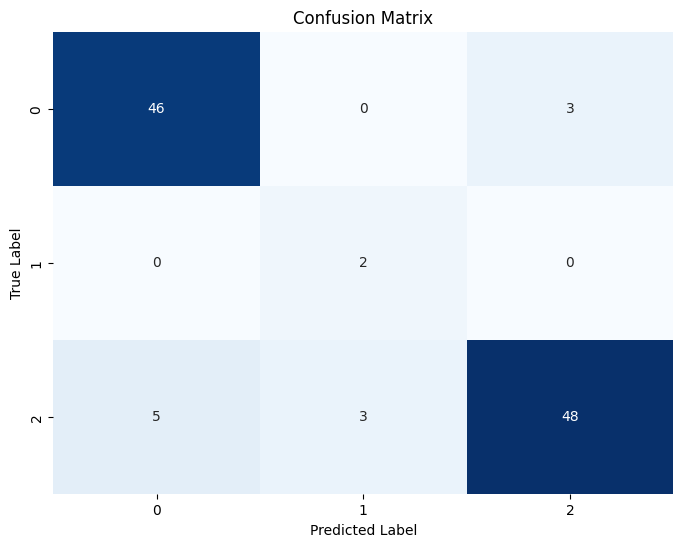

In [ ]:
# prompt: give code to generate confusion matrix, recall, precision and f1-score for every class and overall , and confusion matrix should be in graph form

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Generate the confusion matrix
confusion_matrix = confusion_matrix(y_val.argmax(axis=1), y_pred_classes)

# Generate the classification report
classification_report = classification_report(y_val.argmax(axis=1), y_pred_classes)

# Print the classification report
print("\nClassification Report:")
print(classification_report)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


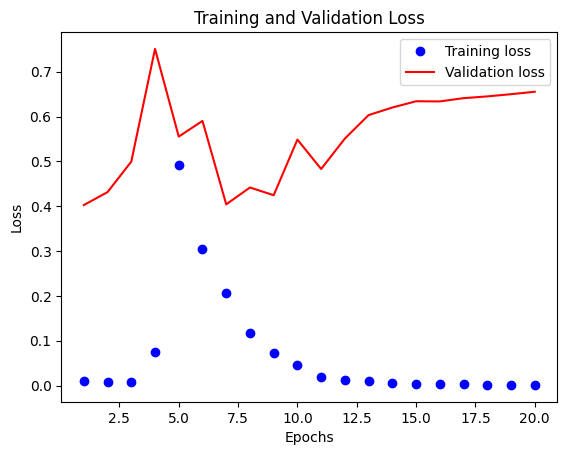

In [ ]:
import matplotlib.pyplot as plt

# Extract training and validation loss from history
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot training and validation loss
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()